# DenseNet121 - OCT Retinal Disease Classification

This notebook performs: data loading from `OCT/train` and `OCT/test`, EDA, class balancing (no augmentation), DenseNet121 transfer learning training, evaluation, and sample predictions.


In [1]:
# 1) Import Required Libraries

import os
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


2025-11-19 19:01:14.609754: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# 2) Parameters and paths

BASE_DIR = Path('./OCT')
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR = BASE_DIR / 'test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
CLASSES = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
print('Classes:', CLASSES)


Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [3]:
# 3) Data Loading (list file paths & labels)

def list_image_files_and_labels(directory, classes):
    files = []
    labels = []
    for idx, cls in enumerate(classes):
        cls_dir = Path(directory) / cls
        if not cls_dir.exists():
            continue
        img_files = list(cls_dir.glob('*'))
        for p in img_files:
            files.append(str(p))
            labels.append(cls)
    return np.array(files), np.array(labels)

train_files, train_labels = list_image_files_and_labels(TRAIN_DIR, CLASSES)
test_files, test_labels = list_image_files_and_labels(TEST_DIR, CLASSES)

print('Train samples:', len(train_files))
print('Test samples:', len(test_files))

train_df = pd.DataFrame({'path':train_files, 'label':train_labels})
test_df = pd.DataFrame({'path':test_files, 'label':test_labels})

train_df.head()

Train samples: 108309
Test samples: 1000


,path,label
0,OCT/train/CNV/CNV-9431642-10.jpeg,CNV
1,OCT/train/CNV/CNV-7513011-150.jpeg,CNV
2,OCT/train/CNV/CNV-1699976-308.jpeg,CNV
3,OCT/train/CNV/CNV-7792808-4.jpeg,CNV
4,OCT/train/CNV/CNV-8819395-2.jpeg,CNV


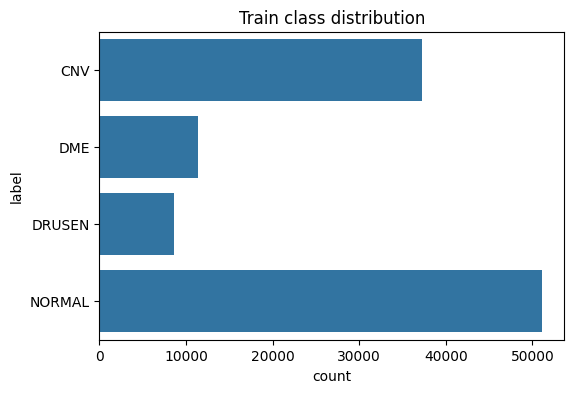

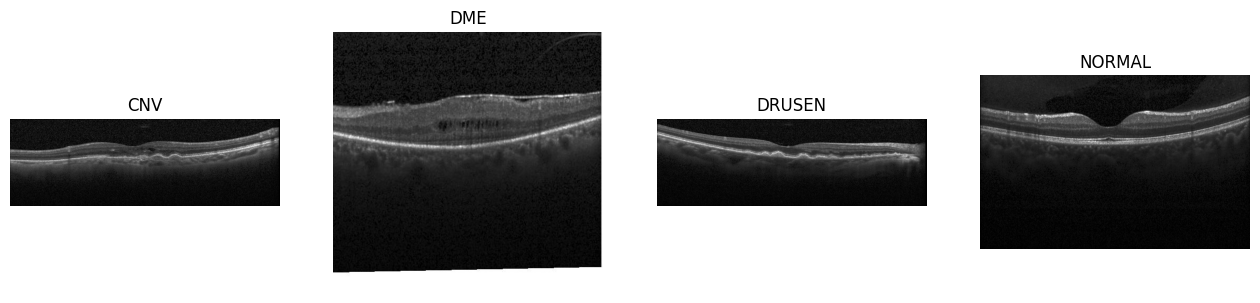

(496, 512)     106
(496, 768)      63
(496, 1536)     18
(512, 512)      13
Name: count, dtype: int64

In [4]:
# 4) EDA: class distribution and sample images

plt.figure(figsize=(6,4))
sns.countplot(y='label', data=train_df, order=CLASSES)
plt.title('Train class distribution')
plt.show()

# show sample images from each class
ncols = len(CLASSES)
plt.figure(figsize=(4*ncols,4))
for i, cls in enumerate(CLASSES):
    sample = train_df[train_df.label==cls].sample(1, random_state=SEED).iloc[0]['path']
    img = plt.imread(sample)
    plt.subplot(1, ncols, i+1)
    plt.imshow(img, cmap='gray' if img.ndim==2 else None)
    plt.title(f"{cls}")
    plt.axis('off')
plt.show()

# image size stats
sizes = []
for p in train_df['path'].sample(min(200, len(train_df)), random_state=SEED):
    img = plt.imread(p)
    sizes.append(img.shape)

pd.Series(sizes).value_counts().head()


In [5]:
# 5) Handle Class Imbalance (undersample to smallest class)

class_counts = train_df['label'].value_counts()
min_count = int(class_counts.min())
print('Class counts before balancing:\n', class_counts)
print('\nDownsampling each class to', min_count, 'samples to create a balanced training set (no augmentation).')

balanced_dfs = []
for cls in CLASSES:
    cls_df = train_df[train_df.label==cls]
    if len(cls_df) > min_count:
        cls_df = cls_df.sample(min_count, random_state=SEED)
    balanced_dfs.append(cls_df)

balanced_train_df = pd.concat(balanced_dfs).sample(frac=1, random_state=SEED).reset_index(drop=True)
print('Balanced train distribution:\n', balanced_train_df['label'].value_counts())


Class counts before balancing:
 label
NORMAL    51140
CNV       37205
DME       11348
DRUSEN     8616
Name: count, dtype: int64

Downsampling each class to 8616 samples to create a balanced training set (no augmentation).
Balanced train distribution:
 label
NORMAL    8616
CNV       8616
DME       8616
DRUSEN    8616
Name: count, dtype: int64


In [6]:
# 6) Data Preprocessing: create tf.data Datasets from balanced list

# helper: load and preprocess image

def decode_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image*255.0)  # DenseNet expects inputs in a certain range
    return image, label

# map labels to indices
label_to_idx = {c:i for i,c in enumerate(CLASSES)}

balanced_paths = balanced_train_df['path'].values
balanced_labels = [label_to_idx[l] for l in balanced_train_df['label'].values]

# split balanced into train/val
train_paths, val_paths, train_lbls, val_lbls = train_test_split(
    balanced_paths, balanced_labels, test_size=0.2, stratify=balanced_labels, random_state=SEED)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_lbls))
train_ds = train_ds.shuffle(len(train_paths), seed=SEED).map(lambda p,l: decode_and_preprocess(p,l), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_lbls))
val_ds = val_ds.map(lambda p,l: decode_and_preprocess(p,l), num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# test dataset (use full test set without balancing)

test_paths = test_df['path'].values
test_labels_idx = [label_to_idx.get(l, -1) for l in test_df['label'].values]

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels_idx))
test_ds = test_ds.map(lambda p,l: decode_and_preprocess(p,l), num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print('Train batches:', tf.data.experimental.cardinality(train_ds).numpy())
print('Val batches:', tf.data.experimental.cardinality(val_ds).numpy())
print('Test batches:', tf.data.experimental.cardinality(test_ds).numpy())


I0000 00:00:1763578924.983332 2401936 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1225 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:21:00.0, compute capability: 8.6
I0000 00:00:1763578925.018643 2401936 cuda_executor.cc:508] failed to allocate 1.20GiB (1285423104 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


Train batches: 862
Val batches: 216
Test batches: 32


In [7]:
# 7) Build DenseNet121 model

base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # transfer learning: freeze base initially

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(CLASSES), activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/20


2025-11-19 19:02:41.141582: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b9b5c003210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-19 19:02:41.141610: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-11-19 19:02:41.853452: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-19 19:02:41.853452: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-19 19:02:45.854902: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91200
2025-11-19 19:02:45.854902: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91200
2025-11-19 19:02:46.888530: I external/local_xla

  5/862 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.3403 - loss: 1.6233

I0000 00:00:1763578982.713637 2469137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


862/862 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3843 - loss: 1.5029

2025-11-19 19:03:58.027081: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3306', 8 bytes spill stores, 8 bytes spill loads

2025-11-19 19:04:17.359191: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3306', 12 bytes spill stores, 12 bytes spill loads

2025-11-19 19:04:17.359191: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3306', 12 bytes spill stores, 12 bytes spill loads



862/862 ━━━━━━━━━━━━━━━━━━━━ 125s 105ms/step - accuracy: 0.4462 - loss: 1.3285 - val_accuracy: 0.6920 - val_loss: 0.8303 - learning_rate: 1.0000e-04
Epoch 2/20
Epoch 2/20
862/862 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.6028 - loss: 0.9650 - val_accuracy: 0.7508 - val_loss: 0.7021 - learning_rate: 1.0000e-04
Epoch 3/20
862/862 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.6028 - loss: 0.9650 - val_accuracy: 0.7508 - val_loss: 0.7021 - learning_rate: 1.0000e-04
Epoch 3/20
862/862 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.6627 - loss: 0.8315 - val_accuracy: 0.7728 - val_loss: 0.6435 - learning_rate: 1.0000e-04
Epoch 4/20
862/862 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.6627 - loss: 0.8315 - val_accuracy: 0.7728 - val_loss: 0.6435 - learning_rate: 1.0000e-04
Epoch 4/20
862/862 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.6973 - loss: 0.7645 - val_accuracy: 0.7866 - val_loss: 0.6091 - learning_rate: 1.0000e-04
Epoch 5/20
862/862 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/s

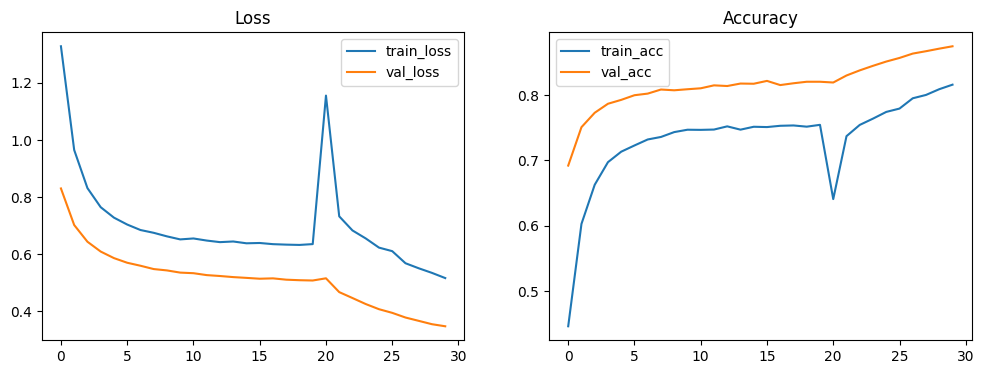

In [8]:
# 8) Train the model (with callbacks)

callbacks = [
    keras.callbacks.ModelCheckpoint('densenet121_balanced_best.keras', save_best_only=True, monitor='val_accuracy', mode='max'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

EPOCHS = 20
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

# Optionally unfreeze some of the base model and fine-tune
base_model.trainable = True
# fine-tune from this layer onwards (small number to avoid large changes)
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ft_history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

# combine histories
for k in history.history:
    history.history[k].extend(ft_history.history.get(k, []))

# plot training
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.show()


862/862 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.8867 - loss: 0.3154
862/862 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.8867 - loss: 0.3154
Train loss: 0.3154, Train accuracy: 0.8867
Train loss: 0.3154, Train accuracy: 0.8867
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


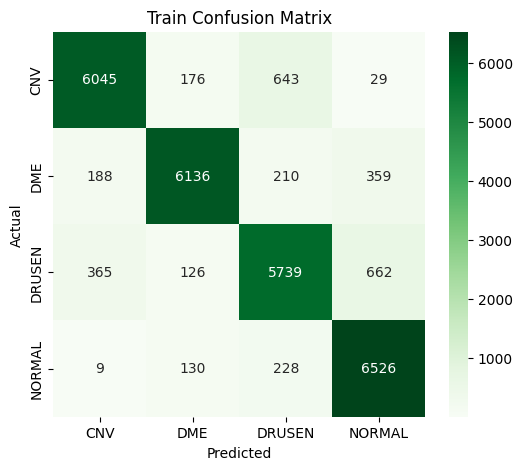

Saved train per-class summary to densenet121_train_per_class_summary.csv


In [13]:
# 8.5) Training set accuracy and per-class metrics
# Evaluate on the (balanced) training dataset and recompute detailed metrics
train_loss, train_acc = model.evaluate(train_ds, verbose=1)
print(f"Train loss: {train_loss:.4f}, Train accuracy: {train_acc:.4f}")

# Recompute predictions on training set for detailed per-class metrics
y_train_true = []
y_train_pred = []
for imgs, labels in train_ds:
    probs = model.predict(imgs)
    preds = np.argmax(probs, axis=1)
    y_train_true.extend(labels.numpy().tolist())
    y_train_pred.extend(preds.tolist())

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
train_acc_re = accuracy_score(y_train_true, y_train_pred)
print(f"Recomputed train accuracy: {train_acc_re:.4f}")
print('\nTrain classification report:')
print(classification_report(y_train_true, y_train_pred, target_names=CLASSES))

cm_train = confusion_matrix(y_train_true, y_train_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Train Confusion Matrix')
plt.show()

# Save train per-class summary
per_class_train = []
for i, cls in enumerate(CLASSES):
    idxs = np.where(np.array(y_train_true) == i)[0]
    total = len(idxs)
    correct = int(np.sum(np.array(y_train_pred)[idxs] == i)) if total > 0 else 0
    per_class_train.append({'class': cls, 'total': total, 'correct': correct, 'incorrect': total-correct, 'accuracy': (correct/total if total>0 else 0.0)})
pd.DataFrame(per_class_train).to_csv('densenet121_train_per_class_summary.csv', index=False)
print('Saved train per-class summary to densenet121_train_per_class_summary.csv')


30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9703 - loss: 0.0996

2025-11-19 19:26:40.708785: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3306', 12 bytes spill stores, 12 bytes spill loads



32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 590ms/step - accuracy: 0.9580 - loss: 0.1390
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 590ms/step - accuracy: 0.9580 - loss: 0.1390
Test loss, Test accuracy: [0.13902825117111206, 0.9580000042915344]
Test loss, Test accuracy: [0.13902825117111206, 0.9580000042915344]
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━

2025-11-19 19:27:32.928556: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


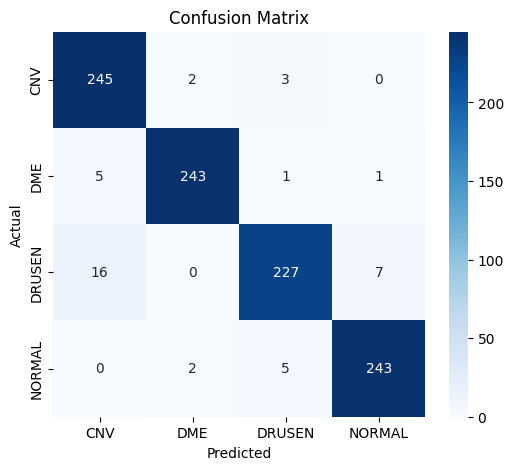

In [9]:
# 9) Evaluate on test set

results = model.evaluate(test_ds)
print('Test loss, Test accuracy:', results)

# Detailed predictions for confusion matrix
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


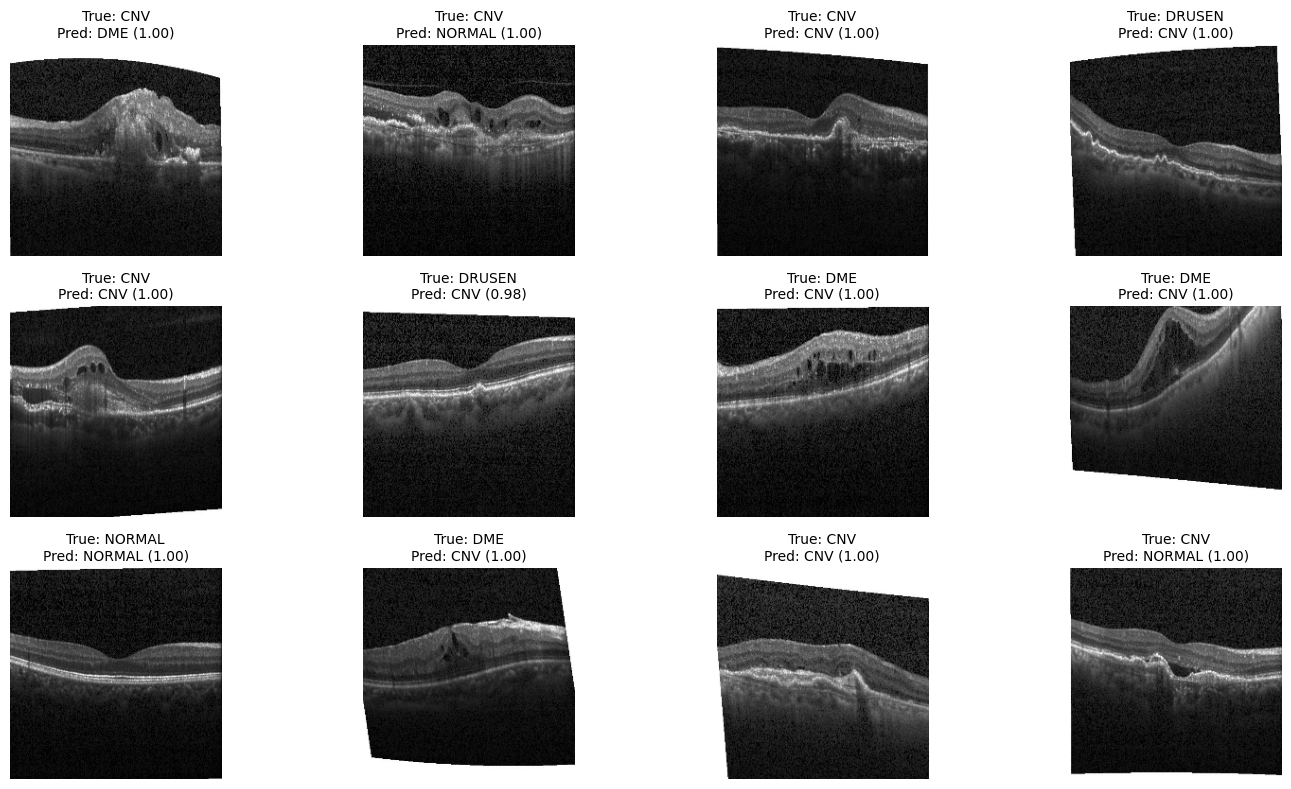

Saved model to densenet121_balanced.keras


In [10]:
# 10) Sample predictions and compare actual vs predicted

num_samples = 12
sample_df = test_df.sample(min(num_samples, len(test_df)), random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(15, 8))
for i, row in sample_df.iterrows():
    img_path = row['path']
    true_label = row['label']
    img = tf.io.read_file(img_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img_in = tf.expand_dims(img, 0)
    img_in = tf.image.convert_image_dtype(img_in, tf.float32)
    img_in = preprocess_input(img_in*255.0)
    pred = model.predict(img_in)
    pred_idx = np.argmax(pred[0])
    pred_label = CLASSES[pred_idx]
    confidence = float(np.max(pred[0]))

    plt.subplot(3, 4, i+1)
    plt.imshow(img.numpy().astype('uint8'))
    title = f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})"
    plt.title(title, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Save final model
model.save('densenet121_balanced.keras')
print('Saved model to densenet121_balanced.keras')


Loading model from: densenet121_balanced_best.keras

Evaluating on balanced train set:

Evaluating on balanced train set:
862/862 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - accuracy: 0.8867 - loss: 0.3154
862/862 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - accuracy: 0.8867 - loss: 0.3154
Train (loss, acc): [0.31535929441452026, 0.8866562843322754]

Evaluating on test set:
 1/32 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9688 - loss: 0.0961Train (loss, acc): [0.31535929441452026, 0.8866562843322754]

Evaluating on test set:
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step - accuracy: 0.9580 - loss: 0.1390
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step - accuracy: 0.9580 - loss: 0.1390
Test (loss, acc): [0.13902825117111206, 0.9580000042915344]
Test (loss, acc): [0.13902825117111206, 0.9580000042915344]
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━

2025-11-19 19:34:40.952867: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


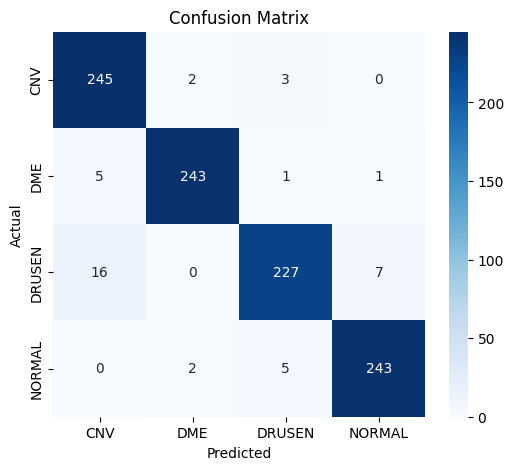

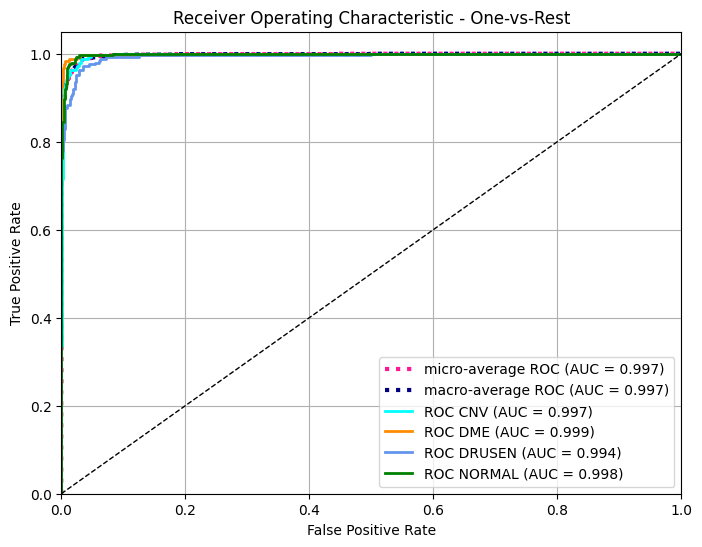


Per-class summary:
    class  total  correct  incorrect  accuracy
0     CNV    250      245          5     0.980
1     DME    250      243          7     0.972
2  DRUSEN    250      227         23     0.908
3  NORMAL    250      243          7     0.972


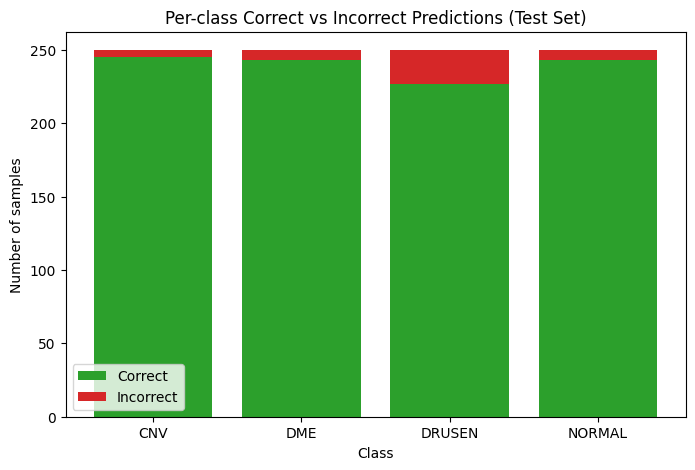

/tmp/ipykernel_2401936/875291021.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='accuracy', data=summary_df, palette='Blues')


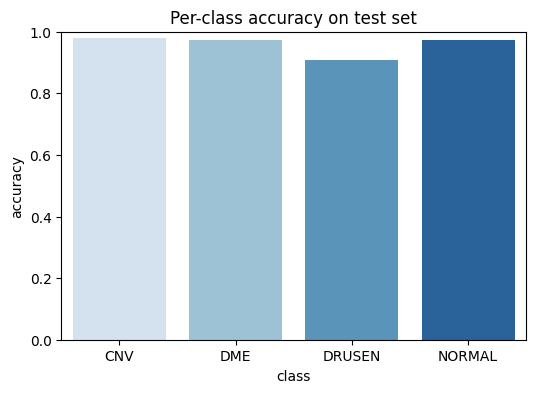


Saved per-class summary to densenet121_test_per_class_summary.csv


In [ ]:
# 12) Detailed evaluation: load best model, ROC curves, per-class analysis

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, accuracy_score

# Prefer the 'best' checkpoint if present
best_model_paths = [p for p in [
    Path('densenet121_balanced_best.keras'),
    Path('densenet121_balanced.keras'),
] if p.exists()]

if len(best_model_paths) == 0:
    raise FileNotFoundError('No model file found. Please ensure the best model checkpoint exists in notebook folder.')

model_path = best_model_paths[0]
print('Loading model from:', model_path)
model = keras.models.load_model(model_path)

# Evaluate on training (balanced) and test sets
print('\nEvaluating on balanced train set:')
train_eval = model.evaluate(train_ds, verbose=1)
print('Train (loss, acc):', train_eval)

print('\nEvaluating on test set:')
test_eval = model.evaluate(test_ds, verbose=1)
print('Test (loss, acc):', test_eval)

# Gather predictions and true labels for the entire test set
y_true = []
y_score = []  # probabilities
for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    y_score.append(preds)
    y_true.extend(batch_labels.numpy().tolist())

y_score = np.vstack(y_score)
y_true = np.array(y_true)

# Predicted classes
y_pred = np.argmax(y_score, axis=1)

# Classification report and confusion matrix (reprint)
print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# One-vs-rest ROC curves
n_classes = len(CLASSES)
y_true_binarized = label_binarize(y_true, classes=list(range(n_classes)))

fpr = dict()
tpr = dict()	
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average ROC
fpr['micro'], tpr['micro'], _ = roc_curve(y_true_binarized.ravel(), y_score.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

# macro-average ROC (interpolate)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr['macro'] = all_fpr
tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr['micro'], tpr['micro'], label=f'micro-average ROC (AUC = {roc_auc["micro"]:.3f})', color='deeppink', linestyle=':', linewidth=3)
plt.plot(fpr['macro'], tpr['macro'], label=f'macro-average ROC (AUC = {roc_auc["macro"]:.3f})', color='navy', linestyle=':', linewidth=3)

colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors[:n_classes]):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC {CLASSES[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - One-vs-Rest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Per-class correctness counts and histogram
per_class_summary = []
for i, cls in enumerate(CLASSES):
    idxs = np.where(y_true == i)[0]
    total = len(idxs)
    correct = int(np.sum(y_pred[idxs] == i)) if total > 0 else 0
    incorrect = total - correct
    per_class_summary.append({'class': cls, 'total': total, 'correct': correct, 'incorrect': incorrect, 'accuracy': (correct/total if total>0 else 0.0)})

summary_df = pd.DataFrame(per_class_summary)
print('\nPer-class summary:')
print(summary_df)

# Histogram: correct vs incorrect per class (stacked)
plt.figure(figsize=(8,5))
plt.bar(summary_df['class'], summary_df['correct'], label='Correct', color='tab:green')
plt.bar(summary_df['class'], summary_df['incorrect'], bottom=summary_df['correct'], label='Incorrect', color='tab:red')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Per-class Correct vs Incorrect Predictions (Test Set)')
plt.legend()
plt.show()

# Additional plots: per-class accuracy bar
plt.figure(figsize=(6,4))
sns.barplot(x='class', y='accuracy', data=summary_df, palette='Blues')
plt.ylim(0,1)
plt.title('Per-class accuracy on test set')
plt.show()

# Save summary to CSV for later analysis
summary_df.to_csv('densenet121_test_per_class_summary.csv', index=False)
print('\nSaved per-class summary to densenet121_test_per_class_summary.csv')
